# 数据预处理

## 缺失值处理

在实际的数据集中，由于设备故障、用户未填写、数据丢失等原因，经常会出现缺失值（Missing Values）。在 Python 中，缺失值通常表示为 NaN（Not a Number）、None 或空字符串。
缺失值的机制与类型
统计学家将缺失值分为以下三种类型，了解它们有助于我们选择更合适的处理方法：
1. 完全随机缺失 (Missing Completely at Random, MCAR):
  - 数据的缺失概率与任何变量（不论是缺失变量本身还是其他完全变量）都无关。例如：实验室中的试管由于不小心摔碎而丢失了测量数据。
2. 随机缺失 (Missing at Random, MAR):
  - 数据的缺失概率与已经观测到的其他变量有关，但与缺失值本身无关。例如：男性比女性更不愿意填写自己的体重，体重的缺失概率与性别（已观测）有关。
  - 数据的缺失概率与缺失值本身有关。例如：高收入人群或极低收入人群往往不倾向于填写自己的真实收入。

__缺失值的检测__

在 pandas 中，我们常用的检测方法有：
- df.isnull() 或 df.isna(): 返回布尔型 DataFrame。
- df.isnull().sum(): 统计每列缺失值的数量。
- df.info(): 查看数据大体结构与非空值数量。

__缺失值处理策略__

__方案 A：删除 (Deletion)__

- 样本删除 (Listwise Deletion): 直接删除含有缺失值的整行数据。
  - 适用场景: 缺失样本比例极低（如 $< 5\%$），且数据量足够大。
- 特征删除 (Pairwise Deletion): 如果某列特征的缺失值比例过高（如 $> 70\%$），且该特征对预测目标不重要，可直接删除该特征（列）。

__方案 B：填充 (Imputation)__

- 统计量填充:
  - 均值 (Mean): 适用于数值型、符合正态分布的特征。
  - 中位数 (Median): 适用于数值型、存在偏态（Skewed）或异常值的特征（中位数更具鲁棒性）。
  - 众数 (Mode): 适用于类别型变量（Categorical features）。
  - 常数填充: 用一个特定值（如 0、-1 或 "Unknown"）填充，保留缺失本身蕴含的信息。
- 模型填充 (Model-based Imputation):
  - KNN 填充 (K-Nearest Neighbors): 寻找最相似的 $K$个样本，用它们的特征均值来填充缺失值。
  - 多重插补 (MICE/Iterative Imputer): 建立回归模型，用其他变量来预测当前缺失变量的值，进行多轮迭代。
- 引入缺失值指示器 (Missing Indicator)
- 增加一个二值化特征（如 is_missing_age），1 表示原本缺失，0 表示原本不缺失。因为“缺失”本身也可能是一个非常有用的特征信号。

In [5]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # 必须先启用 IterativeImputer
from sklearn.impute import IterativeImputer

# 1. 创建模拟数据集
data = {
    '年龄': [25, 30, np.nan, 45, 22, np.nan, 35],
    '收入': [50000, np.nan, 70000, 120000, np.nan, 60000, 85000],
    '性别': ['男', '女', '女', np.nan, '男', '女', np.nan]
}
df = pd.DataFrame(data)
print("--- 原始数据集 ---")
print(df)

# 2. 检测缺失值
print("\n--- 每列缺失值计数 ---")
print(df.isnull().sum())

# 3. 策略 A: 直接删除含有缺失值的行
df_drop_rows = df.dropna()
print("\n--- 删除含有缺失值的行后 ---")
print(df_drop_rows)

# 4. 策略 B: 统计量填充 (使用 pandas)
df_filled = df.copy()
# 数值型用中位数填充
df_filled['年龄'] = df_filled['年龄'].fillna(df_filled['年龄'].median())
df_filled['收入'] = df_filled['收入'].fillna(df_filled['收入'].mean())
# 类别型用众数填充
gender_mode = df_filled['性别'].mode()[0]
df_filled['性别'] = df_filled['性别'].fillna(gender_mode)
print("\n--- 使用 pandas (均值/中位数/众数) 填充后 ---")
print(df_filled)

# 5. 策略 C: 使用 scikit-learn 的 KNN 填充
# 注意：KNN 只能处理数值型数据，我们先提取数值列
numeric_cols = ['年龄', '收入']
knn_imputer = KNNImputer(n_neighbors=2)
df_knn = df.copy()
df_knn[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])
print("\n--- 使用 KNN 算法 (K=2) 填充数值列后 ---")
print(df_knn)

# 6. 策略 D: 引入缺失值指示器
df_indicator = df.copy()
df_indicator['年龄_是否缺失'] = df_indicator['年龄'].isnull().astype(int)
print("\n--- 引入缺失值指示变量后 ---")
print(df_indicator[['年龄', '年龄_是否缺失']])

--- 原始数据集 ---
     年龄        收入   性别
0  25.0   50000.0    男
1  30.0       NaN    女
2   NaN   70000.0    女
3  45.0  120000.0  NaN
4  22.0       NaN    男
5   NaN   60000.0    女
6  35.0   85000.0  NaN

--- 每列缺失值计数 ---
年龄    2
收入    2
性别    2
dtype: int64

--- 删除含有缺失值的行后 ---
     年龄       收入 性别
0  25.0  50000.0  男

--- 使用 pandas (均值/中位数/众数) 填充后 ---
     年龄        收入 性别
0  25.0   50000.0  男
1  30.0   77000.0  女
2  30.0   70000.0  女
3  45.0  120000.0  女
4  22.0   77000.0  男
5  30.0   60000.0  女
6  35.0   85000.0  女

--- 使用 KNN 算法 (K=2) 填充数值列后 ---
     年龄        收入   性别
0  25.0   50000.0    男
1  30.0   67500.0    女
2  30.0   70000.0    女
3  45.0  120000.0  NaN
4  22.0   67500.0    男
5  30.0   60000.0    女
6  35.0   85000.0  NaN

--- 引入缺失值指示变量后 ---
     年龄  年龄_是否缺失
0  25.0        0
1  30.0        0
2   NaN        1
3  45.0        0
4  22.0        0
5   NaN        1
6  35.0        0


# 异常值处理

异常值 (Outliers) 是指在数据集中与大多数观测值显著不同的数据点。异常值可能是由于测量错误（如仪器故障、人工录入笔误）引起的，也可能是真实的极端情况（如金融欺诈行为、超级富豪的资产）。

__为什么要处理异常值？__

许多机器学习模型（特别是基于距离、梯度的模型，如线性回归、逻辑回归、K-Means、神经网络等）对异常值极其敏感。一个巨大的异常值会拉偏回归线，或破坏聚类的效果。
(注：基于树的模型如随机森林、XGBoost 对异常值具有天然的鲁棒性，但预处理仍有必要)

## 异常值检测方法

### 方法 A：3-Sigma（Z-Score）方法

原理: 假设数据服从正态分布（高斯分布）。根据 3-Sigma 原则，约 $99.7\%$ 的数据落在距离均值 3 个标准差内：


$$[\mu - 3\sigma, \mu + 3\sigma]$$


如果某个数据点的 Z-Score 绝对值大于 3，则判定为异常值。

公式:


$$Z = \frac{x - \mu}{\sigma}$$

适用条件: 数据需要基本服从或近似正态分布。

### 方法 B：IQR (四分位距) 方法（箱线图法）

原理: 不需要数据服从正态分布，极其常用。

$Q_1$: 上四分位数（第 25 百分位数）

$Q_3$: 下四分位数（第 75 百分位数）

$IQR$: 四分位距，即 $IQR = Q_3 - Q_1$

正常范围界限:


$$\text{下界} = Q_1 - 1.5 \times IQR$$

$$\text{上界} = Q_3 + 1.5 \times IQR$$

任何低于下界或高于上界的数据点都被定义为异常值（极度异常可以使用 3 倍 IQR）。

### 方法 C：基于模型的算法检测（如 孤立森林 Isolation Forest）

原理: 一种无监督学习算法。它通过随机选择特征并随机选择分割值来构建决策树。因为异常值数量少且特征显著，所以它们更容易在树的浅层就被“孤立”出来。树深度较浅的点更有可能是异常值。

适用条件: 高维数据、非线性数据分布。

## 异常值处理策略

删除 (Drop):

确认是由于测量、录入错误导致的异常值，可以直接删除。

盖帽法 / 缩尾法 (Capping / Windsorization):

不删除数据，而是将超出边界的值替换为边界值。例如：高于 $Q_3 + 1.5 \times IQR$ 的值全部重置为 $Q_3 + 1.5 \times IQR$。

对数转换 (Log Transformation):

通过取对数（如 $y = \log(x + 1)$）或 Box-Cox 变换来收缩极值，使右偏的分布变得更接近正态分布，从而降低异常值的影响。

将异常值视为缺失值 (Treat as NaN):

先把检测出的异常值设为 NaN，然后采用前面学到的“缺失值填充”技术进行插补。

In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# 1. 创建包含异常值的数据集
# 正常人的身高在 150-190cm 之间，我们手动加入两个录入错误的异常值 (350, 12)
np.random.seed(42)
heights = np.random.normal(loc=170, scale=8, size=100).tolist()
heights.extend([350, 12])  # 混入两个异常值

df_height = pd.DataFrame({'身高': heights})
print("--- 数据集前5行及最后3行 ---")
print(df_height.head())
print(df_height.tail(3))

# 2. 方法一：IQR (四分位距) 异常值检测
q1 = df_height['身高'].quantile(0.25)
q3 = df_height['身高'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"\n[IQR 计算结果] Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
print(f"正常区间下界: {lower_bound:.2f}, 正常区间上界: {upper_bound:.2f}")

# 找出异常值
outliers_iqr = df_height[(df_height['身高'] < lower_bound) | (df_height['身高'] > upper_bound)]
print("\n--- IQR 检测到的异常值 ---")
print(outliers_iqr)

# 3. 策略：使用“盖帽法 (Capping)”处理异常值
df_capped = df_height.copy()
df_capped['身高'] = np.where(df_capped['身高'] > upper_bound, upper_bound, df_capped['身高'])
df_capped['身高'] = np.where(df_capped['身高'] < lower_bound, lower_bound, df_capped['身高'])

print("\n--- 盖帽处理后检测出的最大值与最小值 ---")
print(f"处理后最大值: {df_capped['身高'].max():.2f}")
print(f"处理后最小值: {df_capped['身高'].min():.2f}")

# 4. 方法二：使用 孤立森林 (Isolation Forest) 进行检测
# contamination 为异常值的比例估计
iso_forest = IsolationForest(contamination=0.03, random_state=42)
# 拟合模型并进行预测，返回 1 (正常) 或 -1 (异常)
preds = iso_forest.fit_predict(df_height[['身高']])

df_height['是否异常'] = preds
outliers_iso = df_height[df_height['是否异常'] == -1]

print("\n--- 孤立森林检测到的异常值 ---")
print(outliers_iso)

--- 数据集前5行及最后3行 ---
           身高
0  173.973713
1  168.893886
2  175.181508
3  182.184239
4  168.126773
             身高
99   168.123303
100  350.000000
101   12.000000

[IQR 计算结果] Q1: 165.19, Q3: 173.73, IQR: 8.54
正常区间下界: 152.37, 正常区间上界: 186.55

--- IQR 检测到的异常值 ---
             身高
74   149.042039
100  350.000000
101   12.000000

--- 盖帽处理后检测出的最大值与最小值 ---
处理后最大值: 186.55
处理后最小值: 152.37

--- 孤立森林检测到的异常值 ---
             身高  是否异常
31   184.818225    -1
74   149.042039    -1
100  350.000000    -1
101   12.000000    -1


# 特征变换

## 连续变量无量纲化

在许多机器学习算法中，如果特征之间的数值范围差异过大（例如：年收入在 $10000$ 到 $1000000$ 之间，而年龄在 $18$ 到 $80$ 之间），模型在计算距离或进行梯度下降时，数值范围大的特征会产生压倒性的主导作用。因此，我们需要将所有连续变量缩放到相同的标准区间。

### 标准化 (Z-Score Standardization)

底层原理: 转换后的数据均值为 $0$，标准差为 $1$，整体分布结构不变。

数学公式:


$$x' = \frac{x - \mu}{\sigma}$$


其中 $\mu$ 为样本均值，$\sigma$ 为样本标准差。

适用场景:

线性回归、逻辑回归、SVM、KNN、K-Means 聚类等对特征尺度极其敏感的算法。

主成分分析 (PCA) 降维。

特点: 如果数据中含有异常值，由于标准差 $\sigma$ 会受到异常值的影响而变大，标准化后的结果可能会被压缩，但相比归一化，它对异常值的鲁棒性依然更强。

### 归一化 (Min-Max Normalization)

底层原理: 将特征值线性映射到固定的区间（通常是 $[0, 1]$）。

数学公式:


$$x' = \frac{x - X_{\min}}{X_{\max} - X_{\min}}$$

适用场景:

神经网络（梯度下降时有利于参数平稳收敛）。

图像处理（像素灰度值转换为 $[0, 1]$）。

树模型或距离无关算法（但树模型通常不需要无量纲化）。

缺点: 极度不抗异常值。如果数据集里存在一个极大异常值 $X_{\max}$，那么所有正常数据在缩放后都会被极度压缩在接近 $0$ 的极窄区间。

### 鲁棒缩放 (RobustScaler)

底层原理: 针对含有大量异常值或极端极值的数据。它不使用均值和标准差，而是使用中位数（Median）和四分位距（IQR）。

数学公式:


$$x' = \frac{x - \text{Median}(X)}{IQR}$$


其中 $IQR = Q_3 - Q_1$（即第 $75$ 百分位数减去第 $25$ 百分位数）。

特点: 中位数和四分位距不易受极端值（异常值）的影响，因此该方法转换后的核心主体数据分布会非常平稳。

### 最大绝对值缩放 (MaxAbsScaler)

底层原理: 将数据除以该特征的最大绝对值，使特征被缩放到 $[-1, 1]$ 区间。

数学公式:


$$x' = \frac{x}{|X_{\max}|}$$

适用场景: 常用于已经过中心化（以 0 为中心）的数据，或稀疏数据（Sparse Data）。它在缩放时不会破坏数据中的稀疏性（原先为 $0$ 的值在变换后依然为 $0$）。

## 连续变量数据变换

非线性变换（Non-linear Transformation）的目的是改变数据的分布形态。许多传统统计学和线性模型假设特征服从对称的正态分布。若数据分布严重偏斜（右偏、长尾分布），就需要进行数据变换。

### Log 变换 (对数变换)

原理: 对数函数 $y = \log(x)$ 随着 $x$ 的增加，其斜率迅速减小。它能有效“拉近”极大的离群点，并“拉开”微小的低数值点，使右偏的偏态分布转为接近正态分布，并能稳定方差（异方差性）。

数学公式:


$$y = \log(x + 1) \quad (\text{Python 中常用 } \text{np.log1p})$$


(加 1 的目的是防止原始特征中出现 $0$ 值时导致无意义的 $\log(0) = -\infty$)

适用场景:

金融特征：如年收入、商品交易额（GMV）、公司资产等。

互联网计数特征：如点击量、浏览量、转发量。

限制: 原始特征值不能包含负数。

### Box-Cox 变换

原理: 一种高度系统的幂变换方法，它通过寻找一个最佳的参数 $\lambda$，自动将非正态分布的数据转换成接近正态的分布。

数学公式:


$$y^{(\lambda)} = \begin{cases} \frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(x) & \text{if } \lambda = 0 \end{cases}$$

限制: 原始输入特征 $x$ 必须严格大于 0（$x > 0$）。

### Yeo-Johnson 变换

原理: Box-Cox 变换的完美升级版。通过改进的数学公式设计，它不仅继承了 Box-Cox 自动寻找最佳正态化变换的能力，而且支持零和负数的输入。

适用场景: 带有负数值（如利润、温度、坐标变化）且需要强制进行正态化变换的变量。

## 连续变量离散化

连续变量离散化（Discretization / Binning），通常称为分箱，是指将连续的数值型特征映射为离散的区间（即变成有序类别特征）。

### 离散化的核心价值

增强鲁棒性: 离散化可以抹去特征中的高频微小噪点。例如，气温从 $34.8^\circ\text{C}$ 到 $35.1^\circ\text{C}$，在连续模型中可能会引发参数振荡，而分入“高温区间”后，该微小变化被屏蔽，模型更稳定。

引入非线性表达能力: 对于线性模型（如逻辑回归），原本只能学习到一条直线规律。离散化后，每个箱子会被赋予独立的权重。例如，年龄与患病风险往往是“U型关系”（婴儿和老人高，青年低），连续变量系数很难拟合这种关系，但分成“少儿、青年、中年、老年” 4 个箱子后，逻辑回归能为每个箱子分配精准的权重。

特征组合的基石: 离散化后的类别特征极易与其它类别特征进行交叉重组。

### 无监督分箱方法

这些方法在划分区间时不参考目标变量 (Label) 的信息。

| 方法                        | 原理                                                                          | 优点                       | 缺点                             |
| ------------------------- | --------------------------------------------------------------------------- | ------------------------ | ------------------------------ |
| **等宽分箱（Equal Width）**     | 将变量取值范围 ([X_{min}, X_{max}]) 均匀分成 (k) 等份，每份宽度为 (\frac{X_{max}-X_{min}}{k})。 | 计算极其简单、直观。               | 极易受极端异常值影响，可能导致绝大多数样本落入同一个箱子中。 |
| **等频分箱（Equal Frequency）** | 先对数据排序，然后均匀地分成 (k) 组，使每个箱子中的样本数量相同。                                         | 保证各箱子信息量均等，不受异常值偏态分布的影响。 | 可能会把相同或极度接近的值强行划分在两个不同的箱子中。    |
| **K-Means 聚类分箱**          | 利用一维 K-Means 聚类将特征划分为 (k) 个簇，每个簇的边界即为分箱边界。                                  | 能自动、自然地贴合数据的实际物理密度与聚集状态。 | 需要迭代计算，复杂度较高。                  |

### 有监督分箱方法

这些方法在分箱时会结合目标标签 (Label)，使划分后的区间具有更强的预测指向性。

决策树分箱: 建立一棵单变量决策树（如以该特征预测标签），将树模型的叶子节点分裂边界作为最终的分箱截断点。

卡方分箱 (ChiMerge): 一种自底向上的分箱方法。它初始时将每个不同的数值都看作一个单箱，然后计算相邻两个箱子的卡方值，不断合并卡方值最小（即类别分布最相似）的相邻箱子，直到满足设定的停止条件。

## 类别特征转换

大多数机器学习模型无法直接解析 "Beijing", "High School" 这样的字符串，必须将它们转换为模型可读取的数字向量。

### 独热编码 (One-Hot Encoding)

原理: 为该特征的每一个独立取值都创建一个新维度，取值非 $1$ 即 $0$。

数学映射: 假设“颜色”取值有 $[红, 绿, 蓝]$：

红 $\rightarrow [1, 0, 0]$

绿 $\rightarrow [0, 1, 0]$

蓝 $\rightarrow [0, 0, 1]$

应用准则: 适用于类别数较少且无序的特征。如果类别基数（Cardinality）过大（如城市有 $300$ 个），会产生极其稀疏的高维矩阵（维度灾难）。

### 标签编码与顺序编码 (Label & Ordinal Encoding)

原理: 用一个整数对类别特征进行顺序映射。

区分:

标签编码 (Label Encoder): 通常只用于转换目标标签 (Y)，而不适合用于无序特征输入。

顺序编码 (Ordinal Encoder): 用于具有自然顺序关系的输入特征。例如：学历 $[高中, 本科, 硕士]$ $\rightarrow [0, 1, 2]$。大小关系代表了学历的递增，模型可以正确捕捉到这一物理含义。

### 目标编码 (Target Encoding / Mean Encoding)

原理: 针对高基数类别特征（即类别种类极多，不适合做 One-Hot）。它利用每个类别在训练集中对应目标变量（Label）的平均值（或其他统计量）来替代当前类别。

例子: 在预测房价时，对于特征“社区名称”：


$$\text{社区 A 的编码值} = \text{训练集中社区 A 的房子的平均售价}$$

数据泄露防范 (平滑技术):
如果某类别下只有一两个样本，目标均值会产生极大偏差（过拟合）。工业界通常引入全局均值进行平滑：


$$\text{Target\_Encoded} = \frac{n \times \bar{y}_c + m \times \bar{y}_g}{n + m}$$


其中 $n$ 是当前类别的样本量，$\bar{y}_c$ 是当前类别的目标均值，$m$ 是平滑权重因子（超参数），$\bar{y}_g$ 是整个数据集的全局目标均值。

### 频数编码 (Frequency/Count Encoding)

原理: 用该类别在数据集中出现的次数或频率（百分比）来替代类别本身。

适用场景: 当类别的出现频次本身就蕴含了强烈的业务信号时（如：稀有的邮政编码可能对应欺诈高发区）。

## 不规则与衍生特征变换

### 日期/时间特征的周期性变换 (正余弦编码)

日期和时间往往呈周期性循环。例如：一天中 $23$ 点与 $0$ 点虽然数值上差了 $23$，但在实际物理时间轴上仅相差 $1$ 个小时。如果直接作为数值输入，模型很难学到这个闭环关系。

解决方案: 使用正弦（Sine）与余弦（Cosine）将单维周期时间投影到二维的圆周坐标系中。

公式:


$$x_{\sin} = \sin\left(\frac{2 \pi \times \text{time}}{\text{max\_period}}\right)$$

$$x_{\cos} = \cos\left(\frac{2 \pi \times \text{time}}{\text{max\_period}}\right)$$


对于小时（24小时制），$\text{max\_period} = 24$。变换后，$23$ 点和 $0$ 点在二维坐标系中的欧氏距离会非常近。

### 交叉与多项式特征 (Interaction & Polynomials)

当单独的特征表达能力不足时，利用数学组合创造衍生特征可以产生极其强大的模型效果。

多项式特征 (Polynomial Features):
若输入特征为 $[x_1, x_2]$，二阶多项式变换会生成：$[1, x_1, x_2, x_1^2, x_2^2, x_1 x_2]$。

$x_1 x_2$ 就是交叉特征，捕捉了两个特征的协同效应（如：高血压且高年龄的人群患病率会呈爆发式上涨，远超单项叠加）。

乘除比率特征: 结合业务经验，如“月负债额 / 月收入”得到的“负债率”，或“点击数 / 展现数”得到的“点击率 (CTR)”，这类衍生特征往往是决定模型表现的关键。
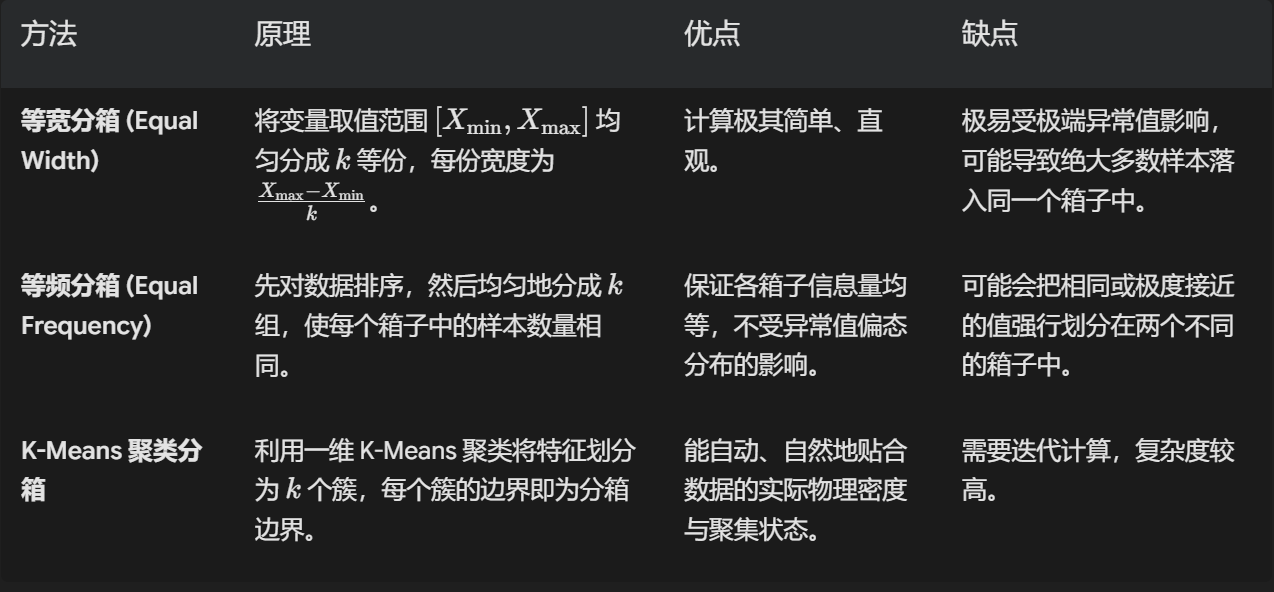

In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PowerTransformer, KBinsDiscretizer, OrdinalEncoder, OneHotEncoder
)

# 1. 构建模拟业务数据集
raw_data = {
    '年龄': [25, 45, 31, 55, 22, 38, 29, 62],
    '年收入_偏态': [50000, 120000, 65000, 450000, 35000, 80000, 72000, 1200000], # 极端右偏
    '异常特征_有偏': [1.2, -0.5, 30.0, 0.1, -1.2, 0.5, 0.3, -50.0],              # 含大异常值
    '学历_有序': ['本科', '硕士', '大专', '博士', '高中', '硕士', '本科', '博士'],
    '城市_无序': ['北京', '上海', '深圳', '北京', '广州', '上海', '深圳', '广州'],
    '注册时间_小时': [23, 14, 2, 7, 22, 11, 1, 12],                              # 周期性时间
    '购买目标': [0, 1, 0, 1, 0, 0, 1, 1]                                         # Y值标签
}

df = pd.DataFrame(raw_data)
print("=================== 原始数据集 ===================")
print(df)

# 用于存储所有变换后新特征的 DataFrame
df_trans = pd.DataFrame()

# ==========================================================
# 1. 连续变量无量纲化
# ==========================================================
# 标准化 (StandardScaler) 适用于大多数正常数据
std_scaler = StandardScaler()
df_trans['年龄_标准化'] = std_scaler.fit_transform(df[['年龄']]).flatten()

# 归一化 (MinMaxScaler) 缩放到 [0, 1]
minmax_scaler = MinMaxScaler()
df_trans['年龄_归一化'] = minmax_scaler.fit_transform(df[['年龄']]).flatten()

# 鲁棒缩放 (RobustScaler) 适用于含异常值的特征
robust_scaler = RobustScaler()
df_trans['异常特征_鲁棒缩放'] = robust_scaler.fit_transform(df[['异常特征_有偏']]).flatten()


# ==========================================================
# 2. 连续变量数据变换 (对数变换 & 幂变换)
# ==========================================================
# Log1p 变换 (针对高度偏态分布，如年收入)
df_trans['年收入_Log变换'] = np.log1p(df['年收入_偏态'])

# Yeo-Johnson 幂变换 (自动搜寻最佳Lambda并使其正态化，支持正负数)
yj_transformer = PowerTransformer(method='yeo-johnson')
df_trans['异常特征_正态化'] = yj_transformer.fit_transform(df[['异常特征_有偏']]).flatten()


# ==========================================================
# 3. 连续变量离散化 (分箱 - 等宽/等频/K-Means)
# ==========================================================
# 使用 KBinsDiscretizer 进行等频分箱 (分成 3 箱，输出类别编码)
kbd_freq = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
df_trans['年龄_等频分箱'] = kbd_freq.fit_transform(df[['年龄']]).flatten()

# 使用 KBinsDiscretizer 进行 K-Means 聚类分箱
kbd_kmeans = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
df_trans['年龄_KMeans分箱'] = kbd_kmeans.fit_transform(df[['年龄']]).flatten()


# ==========================================================
# 4. 类别特征转换
# ==========================================================
# 顺序编码 (OrdinalEncoder) 适用于学历
edu_categories = [['高中', '大专', '本科', '硕士', '博士']]  # 手动指定层级顺序
ord_encoder = OrdinalEncoder(categories=edu_categories)
df_trans['学历_顺序编码'] = ord_encoder.fit_transform(df[['学历_有序']]).flatten()

# 独热编码 (OneHotEncoder) 适用于城市
ohe = OneHotEncoder(sparse_output=False, dtype=int)
ohe_encoded = ohe.fit_transform(df[['城市_无序']])
ohe_cols = [f'城市_{cat}' for cat in ohe.categories_[0]]
df_ohe = pd.DataFrame(ohe_encoded, columns=ohe_cols)


# ==========================================================
# 5. 不规则特征变换与交叉衍生
# ==========================================================
# 日期小时的正弦/余弦编码 (解决 23点 和 0点 的周期连续性问题)
df_trans['时间_Sin'] = np.sin(2 * np.pi * df['注册时间_小时'] / 24.0)
df_trans['时间_Cos'] = np.cos(2 * np.pi * df['注册时间_小时'] / 24.0)

# 高基数或类别目标编码的工程平滑实现 (以城市预测购买目标为例)
def get_target_encoding(dataframe, cat_col, target_col, m_smoothing=2.0):
    global_mean = dataframe[target_col].mean()
    # 计算每个类别的均值和频数
    stats = dataframe.groupby(cat_col)[target_col].agg(['mean', 'count'])
    # 贝叶斯平滑公式
    smooth_encoding = (stats['count'] * stats['mean'] + m_smoothing * global_mean) / (stats['count'] + m_smoothing)
    return dataframe[cat_col].map(smooth_encoding)

df_trans['城市_目标编码'] = get_target_encoding(df, '城市_无序', '购买目标')


# ==========================================================
# 6. 数据变换后的拼接与输出结果展示
# ==========================================================
df_final = pd.concat([df[['年龄', '异常特征_有偏', '年收入_偏态', '学历_有序', '城市_无序', '注册时间_小时']], df_trans, df_ohe], axis=1)

print("\n" + "="*20 + " 第一 & 二部分：无量纲化与偏态变换展示 " + "="*20)
print(df_final[['年龄', '年龄_标准化', '年龄_归一化', '异常特征_有偏', '异常特征_鲁棒缩放', '年收入_偏态', '年收入_Log变换', '异常特征_正态化']].head(5).round(4))

print("\n" + "="*20 + " 第三部分：连续变量分箱变换展示 " + "="*20)
print(df_final[['年龄', '年龄_等频分箱', '年龄_KMeans分箱']].head(5))

print("\n" + "="*20 + " 第四 & 五部分：类别、周期时间与高精目标编码展示 " + "="*20)
print(df_final[['学历_有序', '学历_顺序编码', '城市_无序', '城市_目标编码', '注册时间_小时', '时间_Sin', '时间_Cos']].head(5).round(4))

print("\n" + "="*20 + " 城市独热编码特征展示 " + "="*20)
print(df_final[ohe_cols].head(5))

=================== 原始数据集 ===================
   年龄   年收入_偏态  异常特征_有偏 学历_有序 城市_无序  注册时间_小时  购买目标
0  25    50000      1.2    本科    北京       23     0
1  45   120000     -0.5    硕士    上海       14     1
2  31    65000     30.0    大专    深圳        2     0
3  55   450000      0.1    博士    北京        7     1
4  22    35000     -1.2    高中    广州       22     0
5  38    80000      0.5    硕士    上海       11     0
6  29    72000      0.3    本科    深圳        1     1
7  62  1200000    -50.0    博士    广州       12     1

==================== 第一 & 二部分：无量纲化与偏态变换展示 ====================
   年龄  年龄_标准化  年龄_归一化  异常特征_有偏  异常特征_鲁棒缩放  年收入_偏态  年收入_Log变换  异常特征_正态化
0  25 -0.9874   0.075      1.2     0.7407   50000    10.8198    0.0470
1  45  0.4891   0.575     -0.5    -0.5185  120000    11.6953   -0.0449
2  31 -0.5445   0.225     30.0    22.0741   65000    11.0822    2.0416
3  55  1.2273   0.825      0.1    -0.0741  450000    13.0170   -0.0139
4  22 -1.2089   0.000     -1.2    -1.0370   35000    10.4631   -0.0795

====

D:\dev\Python\AI\machine_learn\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


# 特征提取

## 类别相关的统计特征

在结构化数据（如电商、金融交易记录）中，一个主键（如 User_ID）往往会关联多条流水记录。此时，通过主键聚合类别并计算连续变量的统计特征，能够高度提炼出主键的静态与动态画像。

### 分组聚合的物理意义

以“用户消费”为例：

一个用户多次购买的平均金额代表了其消费档次。

一个用户多次购买金额的标准差代表了其消费决策的波动性/随机性。

一个用户购买金额的最大值代表了其最高消费能力。

### 常见聚合算子

设类别特征（如用户）为 $C$，数值特征（如交易金额）为 $X = \{x_1, x_2, \dots, x_n\}$，以下是提取统计特征时最常用的五个维度：

均值 (Mean):


$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$$

标准差 (Standard Deviation): 反应用户行为的波动程度。


$$\sigma = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu)^2}$$

最大值/最小值 (Max / Min): 寻找边界极值。

中位数 (Median): 当数值存在长尾分布（如少数大额消费）时，比均值更稳定地反映核心消费水平。

## 目标编码的工业界防泄露设计

### 为什么普通目标编码会产生“灾难级过拟合”？

目标编码（Target Encoding）虽然能够将高基数类别（如成千上万个社区名）映射为一维高强度的预测信号，但它有一个致命的缺陷：它直接计算了训练集下当前样本所在类别的目标期望，从而导致严重的数据泄露（Data Leakage）。

特别是在某些样本极少的细分类别中，该类别目标均值几乎等同于单一样本的标签值，模型在训练时会“记住”这些标签，导致在测试集上预测一塌糊涂。

### OOF (Out-of-Fold) 目标编码的设计

为了防止这种泄露，工业界最标准的做法是采用 Out-of-Fold (K-Fold 交叉划分) 方式进行目标编码。

OOF 编码步骤：

将训练集随机均分为 $K$ 个折（Folds，如 $K = 5$）。

对于第 $i$ 折的样本，我们仅使用除第 $i$ 折之外的其余 $K-1$ 折数据来计算各别类的目标均值，然后映射给第 $i$ 折的样本。

对于测试集样本，直接使用整个训练集计算出的全局类别期望进行映射。

这样，任何一个训练样本的目标编码值，都完全没有包含它自身的目标标签信息，从根本上杜绝了过拟合。

[ 训练集 K-Fold 拆分 ]
Fold 1  |  Fold 2  |  Fold 3  |  Fold 4  |  Fold 5
  |
  v (对 Fold 1 计算编码时)
[ 仅基于 Fold 2 + 3 + 4 + 5 数据计算类别均值 ] --> 映射给 Fold 1 样本


## Count、Nunique 与 Ratio 特征

这三类指标在构建风控模型、推荐系统和反作弊模型中起到了举足轻重的作用。

### Count 特征 (频数特征)

定义: 统计某个类别值在当前时间范围或数据集里出现的绝对次数。

物理意义: 反映“活跃度”或“流行度”。

反作弊场景: 在过去 10 分钟内，某个 IP 出现的 Count 暴增，通常预示着自动化攻击行为。

推荐场景: 某个商品被购买的 Count 越高，说明它属于热门爆款。

### Nunique 特征 (多元性特征)

定义: 统计某个类别下，关联的另一个属性的不同取值个数（Number of Unique values）。

物理意义: 描述“关联广度”与“行为分散度”。

信用卡反欺诈: 某个卡号在 1 小时内关联的 IP_address 的 Nunique 达到了 5 个，说明极有可能处于多地盗刷状态。

用户画像: 一个用户看过的电影 category（科幻、喜剧等）的 Nunique 越大，说明其兴趣越广泛。

### Ratio 特征 (比例与相对占比特征)

定义: 将个体的某项局部统计量除以全局或者特定维度的总体统计量，得到相对占比。

公式示例:


$$\text{单次消费占比} = \frac{\text{当前单次消费金额}}{\text{该用户历史消费总金额}}$$

$$\text{工作日消费比例} = \frac{\text{该用户在工作日的购买次数}}{\text{该用户总购买次数}}$$

物理意义: 消除绝对值干扰，从结构和占比角度刻画偏好。

## 类别特征之间交叉组合

很多时候，单个类别特征无法表达特定的复杂业务场景，需要将两个或多个类别特征进行组合（Feature Crosses），产生“1 + 1 > 2”的效果。

### 类别交叉的理论基础

设有两个类别特征：性别 $A \in \{男, 女\}$，学历 $B \in \{高中, 本科, 硕士\}$。
若单独建模，模型只能学习到“性别”和“学历”的独立效应。而交叉组合后，模型能单独挖掘“高学历女性”或“低学历男性”这一细分群体的特殊画像（非线性协同作用）。

### 显式字符串拼接

最简单直观的方法是直接将两列的值用连接符拼接成一列新特征：

"男" $+$ "本科" $\rightarrow$ "男_本科"

随后，对这个新生成的特征列应用 One-Hot 编码或 Target Encoding。

### 处理高维交叉 (维度灾难)

若特征 $A$ 有 $1000$ 个取值，特征 $B$ 有 $1000$ 个取值，两两交叉将产生 $1,000,000$（100万）个可能的组合取值：

频数截断: 仅保留出现频次高于阈值（如 $> 10$ 次）的组合，其余极低频的组合统一归为 "Other"。

Hash 技巧: 对交叉字符串计算 Hash 值并取模，限制其在一个合理的维度区间。

## 时间特征的深度挖掘

在涉及时间序列或有先后顺序的表格数据中，绝对时间是没有意义的，模型必须学习时间上的相对关系与趋势。

### 时间差值 (Time Diffs) 与间隔

提取事件发生时序中的关联时间差：

距离当前时刻的长度: $\text{当前时间} - \text{注册时间}$。

两次相邻事件的间隔: $\text{本次下单时间} - \text{上一次下单时间}$。如果购买间隔越来越短，表明用户近期粘性极强；若间隔突然极长，说明用户可能已经流失。

### 滚动/滑动窗口特征 (Rolling Statistics)

在时序数据中，用户的近期行为比远期行为更有预测价值。这需要我们通过定义固定长度的滑动时间窗口（如近3天、近7天、近30天）来提取统计指标。

                    滑动窗口 [近 3 天]
                    |<-------------->|
Day 1 ---- Day 2 ---- Day 3 ---- Day 4 ---- Day 5 (预测点)


近 3 天消费总额 / 近 30 天消费总额: 刻画用户近期的消费爆发力和整体趋势变化。若比值偏大，说明用户近期在集中采购。

## 多值特征处理

### 什么是多值特征？

在某些场景中，样本的某一个特征不仅包含一个单值，而是包含一个变长的、无序的元素列表（List）。

电影分类: 某部电影的题材是 ['Action', 'Sci-Fi', 'Adventure']。

电商用户: 用户过去一个月购买过的品牌有 ['Nike', 'Adidas', 'Uniqlo']。

### 展开编码（Multi-hot Encoding）

与 One-Hot 编码类似，我们把所有可能出现的元素构成一个全局词表。对于每个样本，凡是列表里包含的元素位置设为 $1$，不包含的设为 $0$。

例: 全局题材库为 [Action, Comedy, Drama, Sci-Fi]。

某电影题材为 ['Action', 'Sci-Fi']，则其 Multi-hot 编码为：$[1, 0, 0, 1]$。

在 Python 中，可以使用 sklearn.preprocessing.MultiLabelBinarizer 快速实现。

### 聚合指标提取与平均嵌入

如果这些多值标签本身携带权重（如用户对这些品牌的好感度评分或消费占比），我们可以提取：

标签个数（如该电影贴了多少个标签）。

平均嵌入（Mean Embedding）：如果是文本标签，可以获取各个标签的 Word Vector 并求均值，将变长标签列表转化为定长的语义向量。

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import MultiLabelBinarizer

# ==========================================================
# 0. 构建模拟流水数据集 (包含用户消费、注册时间、无序偏好及多值标签)
# ==========================================================
np.random.seed(42)

# 模拟 12 条交易流水记录
transaction_data = {
    '交易ID': range(101, 113),
    '用户ID': [1, 2, 1, 3, 2, 1, 3, 2, 1, 2, 3, 1],
    '消费金额': [150.0, 300.0, 50.0, 1200.0, 80.0, 200.0, 450.0, 120.0, 310.0, 90.0, 600.0, 250.0],
    '商户类型': ['餐饮', '数码', '餐饮', '数码', '百货', '娱乐', '百货', '餐饮', '娱乐', '百货', '数码', '餐饮'],
    '交易时间': [
        '2026-06-01 09:00:00', '2026-06-01 10:30:00', '2026-06-02 18:00:00', '2026-06-03 14:00:00',
        '2026-06-04 11:20:00', '2026-06-04 19:40:00', '2026-06-05 09:15:00', '2026-06-06 15:30:00',
        '2026-06-07 21:00:00', '2026-06-08 10:00:00', '2026-06-09 16:45:00', '2026-06-10 12:30:00'
    ],
    '用户喜好标签': [
        ['运动', '数码'], ['美妆', '时尚', '母婴'], ['运动', '户外'], ['极客', '数码', '电竞'],
        ['美妆', '居家'], ['户外', '摄影'], ['极客', '理财'], ['美妆', '美食'],
        ['运动', '摄影'], ['时尚', '居家'], ['电竞', '数码'], ['运动', '健身']
    ],
    '是否违约': [0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0] # Y值，用于演示无泄露目标编码
}

df_raw = pd.DataFrame(transaction_data)
df_raw['交易时间'] = pd.to_datetime(df_raw['交易时间'])

print("==================== 原始流水数据 ====================")
print(df_raw[['交易ID', '用户ID', '消费金额', '商户类型', '交易时间', '是否违约']])

# ==========================================================
# 1. 第一部分：类别关联统计特征 (Groupby Aggregations)
# ==========================================================
# 我们基于用户ID聚合，计算其消费金额的 均值、标准差、最大值、中位数
groupby_feats = df_raw.groupby('用户ID')['消费金额'].agg(['mean', 'std', 'max', 'median']).reset_index()
# 重命名列名，防止特征冲突
groupby_feats.columns = ['用户ID', '用户_消费均值', '用户_消费标准差', '用户_消费最大值', '用户_消费中位数']
# 标准差对于仅出现一次的用户会产生 NaN，填充为 0
groupby_feats['用户_消费标准差'] = groupby_feats['用户_消费标准差'].fillna(0)


# ==========================================================
# 2. 第二部分：K-Fold OOF 目标编码 (防止数据泄露)
# ==========================================================
df_te = df_raw.copy()
df_te['商户类型_目标编码'] = 0.0

kf = KFold(n_splits=3, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(df_te):
    # 分出训练折与验证折
    df_train_fold = df_te.iloc[train_idx]

    # 仅计算训练折各商户类型的目标(是否违约)均值
    fold_te_map = df_train_fold.groupby('商户类型')['是否违约'].mean()

    # 将此均值映射到对应的验证折样本上
    df_te.iloc[val_idx, df_te.columns.get_loc('商户类型_目标编码')] = df_te.iloc[val_idx]['商户类型'].map(fold_te_map)

# 如果有些类别在训练折中未出现，使用全局均值进行平滑填充
global_mean = df_te['是否违约'].mean()
df_te['商户类型_目标编码'] = df_te['商户类型_目标编码'].fillna(global_mean)


# ==========================================================
# 3. 第三部分：Count、Nunique 与 Ratio 特征
# ==========================================================
df_metrics = df_raw.copy()

# 3.1 Count 特征: 统计每个用户在历史中的总交易频次
user_counts = df_metrics['用户ID'].value_counts()
df_metrics['用户_总交易频次'] = df_metrics['用户ID'].map(user_counts)

# 3.2 Nunique 特征: 统计每个用户去过多少个“不同”的商户类型
user_nunique = df_metrics.groupby('用户ID')['商户类型'].nunique()
df_metrics['用户_商户类型多元度'] = df_metrics['用户ID'].map(user_nunique)

# 3.3 Ratio 特征: 单次交易金额占该用户交易总额的比例
user_sum_amt = df_metrics.groupby('用户ID')['消费金额'].transform('sum')
df_metrics['单次金额_占总额比例'] = df_metrics['消费金额'] / user_sum_amt


# ==========================================================
# 4. 第四部分：类别特征交叉组合 (Feature Crosses)
# ==========================================================
# 将 “用户ID” 与 “商户类型” 显式交叉组合
df_metrics['用户_商户_交叉'] = df_metrics['用户ID'].astype(str) + "_" + df_metrics['商户类型']


# ==========================================================
# 5. 第五部分：时间特征的深度提取 (时间差与滚动窗)
# ==========================================================
df_time = df_raw.copy().sort_values(by=['用户ID', '交易时间'])

# 5.1 时间差值 (Time Diffs): 计算该用户本次购买与上一次购买的时间差（单位：小时）
df_time['上一次交易时间'] = df_time.groupby('用户ID')['交易时间'].shift(1)
df_time['与上次交易间隔_小时'] = (df_time['交易时间'] - df_time['上一次交易时间']).dt.total_seconds() / 3600.0
df_time['与上次交易间隔_小时'] = df_time['与上次交易间隔_小时'].fillna(-1.0) # 无历史交易的填充为 -1

# 5.2 滚动窗口统计 (Rolling Window): 计算该用户过去 3 天内(含当天)的累计消费总额
# 为了使用 pandas 的 rolling 窗口，需要将时间设为索引
df_time.set_index('交易时间', inplace=True)
# 按用户ID分组，在 3 天 (3D) 的滑动时间窗口内累计消费金额
df_time['用户_3天内累计消费'] = df_time.groupby('用户ID')['消费金额'].rolling('3D').sum().reset_index(level=0, drop=True)
df_time.reset_index(inplace=True)


# ==========================================================
# 6. 第六部分：多值特征处理 (Multi-valued Features)
# ==========================================================
# 6.1 使用 MultiLabelBinarizer 进行标签展开 (Multi-hot Encoding)
mlb = MultiLabelBinarizer()
multihot_encoded = mlb.fit_transform(df_raw['用户喜好标签'])
multihot_cols = [f'喜好标签_{label}' for label in mlb.classes_]
df_multihot = pd.DataFrame(multihot_encoded, columns=multihot_cols)

# 6.2 提取多值特征衍生指标：喜好标签总个数
df_multihot_metrics = pd.DataFrame()
df_multihot_metrics['喜好标签个数'] = df_raw['用户喜好标签'].apply(len)


# ==========================================================
# 7. 特征合并与展现
# ==========================================================
# 合并主表特征
df_final = df_raw[['交易ID', '用户ID', '消费金额', '商户类型', '交易时间', '是否违约']].copy()

# 合并 Groupby 统计特征
df_final = df_final.merge(groupby_feats, on='用户ID', how='left')

# 合并目标编码特征
df_final['商户类型_OOF目标编码'] = df_te['商户类型_目标编码']

# 合并 Count, Nunique, Ratio & 交叉特征
df_final['用户_总交易频次'] = df_metrics['用户_总交易频次']
df_final['用户_商户类型多元度'] = df_metrics['用户_商户类型多元度']
df_final['单次金额_占总额比例'] = df_metrics['单次金额_占总额比例']
df_final['用户_商户_交叉'] = df_metrics['用户_商户_交叉']

# 合并时间差值及滚动窗口特征
# 注意：df_time 是排序过的，为保证行顺序一致，我们通过 交易ID 进行 merge
df_time_features = df_time[['交易ID', '与上次交易间隔_小时', '用户_3天内累计消费']]
df_final = df_final.merge(df_time_features, on='交易ID', how='left')

# 合并多值特征
df_final = pd.concat([df_final, df_multihot_metrics, df_multihot], axis=1)

print("\n" + "="*20 + " 1. 类别统计特征与 OOF 目标编码结果 " + "="*20)
cols_show_1 = ['用户ID', '消费金额', '用户_消费均值', '用户_消费标准差', '商户类型', '商户类型_OOF目标编码']
print(df_final[cols_show_1].head(6).round(3).to_string(index=False))

print("\n" + "="*20 + " 2. Count, Nunique, Ratio & 交叉特征结果 " + "="*20)
cols_show_2 = ['用户ID', '商户类型', '用户_总交易频次', '用户_商户类型多元度', '单次金额_占总额比例', '用户_商户_交叉']
print(df_final[cols_show_2].head(6).round(3).to_string(index=False))

print("\n" + "="*20 + " 3. 时间间隔差值与滚动窗口特征结果 " + "="*20)
cols_show_3 = ['用户ID', '交易时间', '消费金额', '与上次交易间隔_小时', '用户_3天内累计消费']
print(df_final[cols_show_3].sort_values(by=['用户ID', '交易时间']).head(6).round(3).to_string(index=False))

print("\n" + "="*20 + " 4. 多值标签展开 (Multi-hot Encoding) 结果 " + "="*20)
# 展现前五个标签及标签总个数
cols_show_4 = ['交易ID', '喜好标签个数'] + multihot_cols[:5]
print(df_final[cols_show_4].head(6).to_string(index=False))

==================== 原始流水数据 ====================
    交易ID  用户ID    消费金额 商户类型                交易时间  是否违约
0    101     1   150.0   餐饮 2026-06-01 09:00:00     0
1    102     2   300.0   数码 2026-06-01 10:30:00     1
2    103     1    50.0   餐饮 2026-06-02 18:00:00     0
3    104     3  1200.0   数码 2026-06-03 14:00:00     0
4    105     2    80.0   百货 2026-06-04 11:20:00     1
5    106     1   200.0   娱乐 2026-06-04 19:40:00     0
6    107     3   450.0   百货 2026-06-05 09:15:00     0
7    108     2   120.0   餐饮 2026-06-06 15:30:00     1
8    109     1   310.0   娱乐 2026-06-07 21:00:00     0
9    110     2    90.0   百货 2026-06-08 10:00:00     1
10   111     3   600.0   数码 2026-06-09 16:45:00     0
11   112     1   250.0   餐饮 2026-06-10 12:30:00     0

==================== 1. 类别统计特征与 OOF 目标编码结果 ====================
 用户ID   消费金额  用户_消费均值  用户_消费标准差 商户类型  商户类型_OOF目标编码
    1  150.0    192.0    99.096   餐饮         0.333
    2  300.0    147.5   103.078   数码         0.000
    1   50.0    192.0    99.096

C:\Users\13127\AppData\Local\Temp\ipykernel_13224\4290796084.py:163: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df_final[cols_show_3].sort_values(by=['用户ID', '交易时间']).head(6).round(3).to_string(index=False))


# 特征选择

## 特征关联性分析

过滤法（Filter Methods）通过计算特征本身的统计学指标来独立评估其重要性，不依赖特定的机器学习模型。

### 线性相关性 (Linear Correlation)

相关系数用于衡量两个连续变量之间的关联强度。

#### 皮尔逊相关系数 (Pearson Correlation)

原理: 衡量两个变量之间的线性相关程度。

数学公式:


$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2 \sum_{i=1}^{n} (y_i - \bar{y})^2}}$$

取值区间: $[-1, 1]$。$1$ 代表完全正相关，$-1$ 代表完全负相关，$0$ 代表无线性相关。

适用场景: 连续变量，且数据呈正态分布。

#### 斯皮尔曼等级相关系数 (Spearman Rank Correlation)

原理: 利用变量的“秩次”（排序等级）而非数值本身进行计算。

数学公式:


$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$


其中 $d_i$ 是两个变量等级之间的差值。

优点: 属于非参数统计方法。对异常值极不敏感，且能有效捕捉非线性但单调（Monotonic）的关系。

#### 多重共线性与 VIF (Variance Inflation Factor)

在多变量建模中，如果两个或多个特征之间存在极高的线性相关性，称为多重共线性（Multicollinearity）。这会导致线性模型的系数估计极度不稳定，方差爆炸。

方差膨胀因子 (VIF)

原理: 将某一个特征 $X_i$ 作为目标变量，用其余所有的特征去对它进行线性回归。如果能被轻松预测，说明 $X_i$ 是多余的。

数学公式:


$$VIF_i = \frac{1}{1 - R_i^2}$$


其中 $R_i^2$ 是以 $X_i$ 为因变量、其余特征为自变量进行拟合所得的决定系数（拟合优度）。

判定标准:

$VIF < 5$: 共线性很弱（安全）。

$VIF \ge 10$: 存在严重的共线性，通常需要剔除对应的冗余特征。

#### 非线性关联：互信息 (Mutual Information)

Pearson 系数无法检测非线性关系（例如 $y = x^2$ 构成完美的抛物线，但 Pearson 相关系数却接近 $0$）。互信息（MI）是基于信息熵的高级工具，能检测出任意非线性相关性。

原理: 衡量已知特征 $X$ 的情况下，目标变量 $Y$ 的不确定性（信息熵）减少了多少。

数学公式:


$$I(X; Y) = \sum_{x \in X} \sum_{y \in Y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)}$$

特点: 取值 $\ge 0$。值越大，说明特征 $X$ 对预测 $Y$ 携带的信息量越大。若 $I(X;Y) = 0$，说明两个变量完全独立。

## 特征重要性分析

嵌入法（Embedded Methods）在模型训练的过程中自动计算特征贡献度，并将特征选择作为算法的一部分（如树模型与正则化回归）。

### 树模型的内置重要性 (MDI)

在随机森林、XGBoost、LightGBM 等树模型中，默认使用的重要性指标通常是 MDI (Mean Decrease in Impurity，平均不纯度减少量)，也称为 Gini 重要性。

工作原理: 统计该特征在树的所有分裂节点上，带来的不纯度（如 Gini 指数或 Entropy 熵）下降值的加权和。

致命缺点 (偏置效应):

MDI 会严重偏向于高基数（High Cardinality）特征。对于具有大量唯一值的连续特征（如带有小数点的数值）或高类别数特征（如用户 ID），树模型很容易频繁选择它们进行分裂，从而导致这类特征的 MDI 指标虚高。

### 置换重要性 (Permutation Importance) —— 更科学的评估

为了消除 MDI 的偏置，工业界更推崇置换重要性（Permutation Importance）。

工作步骤：

用原始数据集训练好模型，并计算其在验证集上的原始得分（如 $AUC = 0.85$）。

保持其它特征不变，随机打乱（Permute）特征 $X_i$ 的取值顺序，打破该特征与目标标签 $Y$ 之间的对应关系。

重新输入修改后的数据集进行预测，计算新的模型得分（如 $AUC = 0.65$）。

该特征的置换重要性 = $\text{原始得分} - \text{置换后的得分} = 0.20$。

优势：

属于模型无关（Model-agnostic）方法，适用于任何算法。

不会偏向连续或高基数特征，结果真实反映了特征缺失后对模型泛化的破坏力。

### 基于 L1 正则化 (Lasso) 的特征稀疏化

线性模型通过引入 L1 正则化（即 Lasso 回归），可以强制将某些不重要特征的权重系数缩减为精确的 $0$。

数学损失函数:


$$\text{Loss} = \sum_{i=1}^{m} (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^{d} |w_j|$$

稀疏化机制: L1 范数的几何边界是带有尖角的约束空间（在多维下是超八面体）。等高线首次触碰到这个约束边界时，极大概率会落在坐标轴（即某个 $w_j = 0$ 的点）上，从而天然实现了特征剔除。

## 封装方法 (Wrapper Methods)

封装方法（Wrapper Methods）将特征选择看作是一个“搜索问题”。它配置一个外部黑盒分类器/回归器，通过不断构建不同的特征组合子集来训练模型，并根据模型的最终预测得分来决定特征的去留。

[ 开始特征集 ] ---> [ 生成候选特征子集 ] ---> [ 训练机器学习模型 ] ---> [ 评估性能得分 ]
                            ^                                             |
                            |__________________ 反馈迭代 _________________|


### 递归特征消除 (RFE / RFECV)

递归特征消除（Recursive Feature Elimination, RFE）是一种高效的贪心搜索策略。

工作流程：

初始化包含全部 $D$ 个特征的集合。

在该特征集上训练基模型（基模型必须能输出系数权重，如线性模型系数或树模型重要性）。

丢弃重要性得分最低的一个（或一部分）特征。

在剩余的特征集上重复训练，并再次剔除最低者。

递归进行，直到特征集大小缩减至用户预设的 $k$。

RFECV (带交叉验证的 RFE)：在上述循环中加入交叉验证（Cross-validation），自动寻找到泛化得分最高时的最佳特征个数。

### 序列特征选择 (SFS)

#### 前向选择 (Forward Selection)

初始状态: 特征子集为空。

步骤:

第一轮：测试每个单特征模型，选择准确率最高的那个（设为 $X_a$）加入子集。

第二轮：将剩余特征依次与 $X_a$ 组合，选择使得双特征模型得分最高的组合加入子集。

循环迭代，直到模型性能不再提升或达到设定特征数。

#### 后向选择 (Backward Elimination)

初始状态: 包含所有原始特征。

步骤: 尝试依次移除每一个特征，衡量模型性能的下滑程度。移除掉那个“移除后模型性能下降最少（甚至不降反升）”的特征。不断缩减，直到满足终止条件。

## 特征选择的工业界黄金准则

在实际的业务算法建模中，进行特征选择应遵循以下流程：

零特征方差过滤 (Variance Threshold)：优先剔除常数值或接近常数的特征（例如：全样本中 $99\%$ 都是同一数值的特征）。

缺失值比例过滤：剔除缺失比例超出阈值（如 $> 80\%$）且没有强力业务解释性的特征。

高关联/多重共线性剔除：

寻找相关性极高（如 Pearson $> 0.85$）的特征对，保留与目标变量互信息（MI）更大的那一列，剔除另一列。

检查 VIF 指标，逐步剔除 $VIF > 10$ 的高共线性变量。

置换重要性与 RFE 精筛：使用 Permutation Importance 或 RFECV 进行最终的建模精筛，保留业务可解释且高贡献的 Top $N$ 个特征。

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================================
# 0. 构建模拟数据集 (包含线性相关、非线性、共线性以及纯噪声特征)
# ==========================================================
np.random.seed(42)
n_samples = 800

# 生成基础的分类特征
X, y = make_classification(
    n_samples=n_samples, n_features=5, n_informative=3,
    n_redundant=1, n_classes=2, random_state=42
)

df = pd.DataFrame(X, columns=['feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5'])

# 制造多重共线性：feat_colinear 几乎完全线性依赖于 feat_1
df['feat_colinear'] = df['feat_1'] * 2.5 + np.random.normal(0, 0.1, n_samples)

# 制造非线性关系：feat_nonlinear 与标签具有强二次非线性关联
# 线性 Pearson 相关系数无法很好捕捉它，但互信息可以
df['feat_nonlinear'] = (y ** 2) * np.random.normal(5, 1, n_samples)

# 制造纯随机噪声特征 (对预测完全无用)
df['feat_noise_1'] = np.random.uniform(-10, 10, n_samples)
df['feat_noise_2'] = np.random.normal(0, 5, n_samples)

print("==================== 数据集特征一览 ====================")
print(df.head(3).to_string(index=False))


# ==========================================================
# 1. 关联性分析 (Correlation & VIF)
# ==========================================================
print("\n" + "="*15 + " 1. 关联性分析与多重共线性 " + "="*15)

# 1.1 计算 Pearson 相关系数矩阵
corr_matrix = df.corr().abs()
print("\n--- 特征之间的 Pearson 相关系数矩阵 (局部) ---")
print(corr_matrix[['feat_1', 'feat_colinear', 'feat_nonlinear']].round(3))

# 1.2 计算 VIF 诊断共线性
# 为计算 VIF，必须手动加上常数截距项
vif_df = pd.DataFrame()
vif_df["特征"] = df.columns
vif_df["VIF_值"] = [
    variance_inflation_factor(df.values, i)
    for i in range(df.shape[1])
]
print("\n--- 特征共线性 VIF 诊断结果 (VIF >= 10 应考虑剔除) ---")
print(vif_df.round(3).to_string(index=False))


# ==========================================================
# 2. 非线性关系探测：互信息 (Mutual Information)
# ==========================================================
print("\n" + "="*15 + " 2. 非线性互信息探测 (MI) " + "="*15)
mi_scores = mutual_info_classif(df, y, random_state=42)
mi_df = pd.DataFrame({'特征': df.columns, '互信息得分': mi_scores}).sort_values(by='互信息得分', ascending=False)
print(mi_df.round(4).to_string(index=False))


# ==========================================================
# 3. 嵌入法特征选择 (树模型内置重要性 MDI vs 置换重要性)
# ==========================================================
print("\n" + "="*15 + " 3. 树模型内置重要性 vs 置换重要性 " + "="*15)

X_train, X_val, y_train, y_val = train_test_split(df, y, test_size=0.3, random_state=42)

# 训练随机森林模型作为基分类器
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3.1 提取 MDI 重要性
mdi_importances = rf.feature_importances_
importance_df = pd.DataFrame({
    '特征': df.columns,
    'MDI_内置重要性': mdi_importances
})

# 3.2 提取验证集上的置换重要性 (Permutation Importance)
perm_result = permutation_importance(rf, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
importance_df['置换重要性_均值'] = perm_result.importances_mean

print(importance_df.sort_values(by='置换重要性_均值', ascending=False).round(4).to_string(index=False))


# ==========================================================
# 4. 封装法：递归特征消除 (RFE)
# ==========================================================
print("\n" + "="*15 + " 4. 递归特征消除 (RFE) 筛选前 4 个特征 " + "="*15)

# 使用前面拟合好的随机森林作为 RFE 的底层评估器
rfe = RFE(estimator=rf, n_features_to_select=4, step=1)
rfe.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    '特征': df.columns,
    '是否保留': rfe.support_,
    '选择排序_越小越优先': rfe.ranking_
}).sort_values(by='选择排序_越小越优先')

print(rfe_df.to_string(index=False))

==================== 数据集特征一览 ====================
   feat_1    feat_2    feat_3    feat_4    feat_5  feat_colinear  feat_nonlinear  feat_noise_1  feat_noise_2
-2.652211  0.290853 -0.134870 -0.250140  2.424780      -6.580857        0.000000      6.128072      0.529472
 1.214898  1.370410 -0.748487  1.591411 -2.455343       3.023419        4.483955     -0.815202      2.922065
-0.526714 -0.980987 -2.119607 -1.321011  2.009726      -1.252015        0.000000     -8.960868      9.882203

=============== 1. 关联性分析与多重共线性 ===============

--- 特征之间的 Pearson 相关系数矩阵 (局部) ---
                feat_1  feat_colinear  feat_nonlinear
feat_1           1.000          1.000           0.364
feat_2           0.046          0.046           0.002
feat_3           0.097          0.098           0.362
feat_4           0.025          0.024           0.791
feat_5           0.658          0.657           0.818
feat_colinear    1.000          1.000           0.364
feat_nonlinear   0.364          0.364           1.000

D:\dev\Python\AI\machine_learn\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


            特征  MDI_内置重要性  置换重要性_均值
feat_nonlinear     0.4617    0.4967
        feat_1     0.0312    0.0000
        feat_2     0.0022    0.0000
        feat_4     0.2080    0.0000
        feat_3     0.0319    0.0000
        feat_5     0.2439    0.0000
 feat_colinear     0.0154    0.0000
  feat_noise_1     0.0032    0.0000
  feat_noise_2     0.0027    0.0000

=============== 4. 递归特征消除 (RFE) 筛选前 4 个特征 ===============
            特征  是否保留  选择排序_越小越优先
        feat_1  True           1
        feat_4  True           1
feat_nonlinear  True           1
        feat_5  True           1
 feat_colinear False           2
        feat_3 False           3
  feat_noise_2 False           4
  feat_noise_1 False           5
        feat_2 False           6
